# HITL Exercise: Human-in-the-Loop with `interrupt()` and `Command`

This notebook gives you **2 versions** of the same challenge.

**Goal:** add a **Human-in-the-Loop (HITL)** approval step to a ReAct agent that pauses
execution *before* calling the search tool and waits for your explicit permission.

You will implement:

1. **Version 2.5-HITL** — Extend the manual ReAct graph from Version 2.5 by inserting
   an approval node that uses `interrupt()` + `Command`.
2. **Version 3-HITL** — Use `create_agent` with `interrupt_before=["tools"]`
   and a `MemorySaver` checkpointer to get the same behavior automatically.

> **Prerequisite:** Complete `graph_search_tools_exercise.ipynb` (especially Version 2.5)
> before starting this notebook.

## Shared Setup (Run Once)

Instructions:
1. Run this cell first — both versions depend on it.
2. It loads API keys, creates the shared LLM, and defines the `tavily_search` tool.
3. Set `MODEL_PROVIDER = "gemini"` or `MODEL_PROVIDER = "openai"` to choose your model.

In [5]:
import os
import logging
from typing import TypedDict, Literal

from dotenv import load_dotenv

from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.types import Command, interrupt
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_openai import ChatOpenAI
from langchain.agents import create_agent
from tavily import TavilyClient

logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(message)s")
logger = logging.getLogger(__name__)

# ── Model selection ───────────────────────────────────────────────────────────
MODEL_PROVIDER = "gemini"  # "gemini" | "openai"

# ── Load API keys ─────────────────────────────────────────────────────────────
load_dotenv()

GEMINI_API_KEY = os.getenv("GEMINI_API_KEY")
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
TAVILY_API_KEY = os.getenv("TAVILY_API_KEY")

assert TAVILY_API_KEY, "TAVILY_API_KEY not found — check your .env file"

# ── Shared LLM ────────────────────────────────────────────────────────────────
if MODEL_PROVIDER == "openai":
    assert OPENAI_API_KEY, "OPENAI_API_KEY not found — check your .env file"
    llm = ChatOpenAI(
        model="gpt-4o-mini",
        api_key=OPENAI_API_KEY,
        temperature=0,
    )
else:
    assert GEMINI_API_KEY, "GEMINI_API_KEY not found — check your .env file"
    llm = ChatGoogleGenerativeAI(
        model="gemini-2.5-flash",
        google_api_key=GEMINI_API_KEY,
        temperature=0,
    )

# ── Shared Tavily search tool ─────────────────────────────────────────────────
_tavily_client = TavilyClient(api_key=TAVILY_API_KEY)

@tool
def tavily_search(query: str) -> str:
    """Search on the internet using Tavily and return a concise answer.
    This tool will return multiple results, try to use it efficiently.
    Don't call this tool too many times for 1 question, 1 to 2 calls per query from user are enough.
    Give a concise query.

    Args:
        query: A concise query to search on the internet.
    Returns:
        A concise answer to the user's query.
    """
    logger.info("tavily_search called | query=%s", query)
    response = _tavily_client.search(query=query, max_results=3)
    snippets = [r.get("content", "") for r in response.get("results", [])]
    result = "\n\n".join(snippets) if snippets else "No results found."
    logger.info("tavily_search done | %d snippets returned", len(snippets))
    return result


logger.info("Setup complete — LLM: %s | Tavily tool ready", llm.model)

INFO | Setup complete — LLM: gemini-2.5-flash | Tavily tool ready


## Version 2.5-HITL: Manual ReAct + `interrupt()` Approval

### What you will build
Extend the Version 2.5 manual ReAct graph to pause **before executing any tool call**.
A new `human_approval_node` sits between the model node and the tools node.

### How `interrupt()` works
1. Call `interrupt(payload)` inside a node — execution **pauses immediately**.
2. LangGraph saves the graph state via the checkpointer.
3. The payload you passed appears in `result["__interrupt__"]` so you can show it to the user.
4. Resume by calling the graph again with `Command(resume=<value>)` using the **same thread ID**.
5. `<value>` becomes the **return value** of the `interrupt()` call, and the node continues.

### Graph shape
```
START → model → (tool_calls?) → human_approval → tools → model → …
                              ↘ END (no tool calls)
```

### Your task
1. Implement **`human_approval_node`** — pause with `interrupt()`, then route via `Command`.
2. Implement **`v25_hitl_route`** — send tool-calling responses to `human_approval`, else END.
3. Build + compile the graph **with a `MemorySaver` checkpointer** (required for `interrupt`).

### Key rules for `interrupt()`
- ⚠️ Never wrap `interrupt()` in a bare `try/except Exception` — it works by raising a special exception.
- ⚠️ A **checkpointer is mandatory** — without it the graph will raise an error at runtime.
- ⚠️ Always use the **same `thread_id`** when resuming a paused graph.

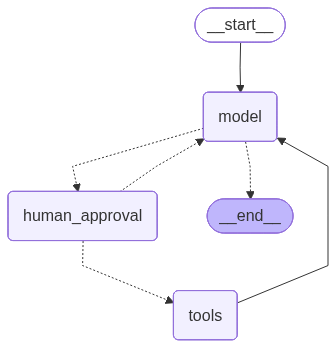

Version 2.5-HITL graph compiled successfully.


In [6]:
# TODO: Complete Version 2.5-HITL implementation

# ── System prompt ─────────────────────────────────────────────────────────────
V25_HITL_SYSTEM_PROMPT = (
    "You are a helpful assistant. "
    "Use the search tool to look up information about the user's query. "
    "Only call the tool one time per query."
)

# ── LLM with tools bound (given) ──────────────────────────────────────────────
llm_with_tools = llm.bind_tools([tavily_search])


# ── Model node (given) ────────────────────────────────────────────────────────
def v25_hitl_model_node(state: MessagesState) -> dict:
    """Calls the LLM with the full message history. Routes to human_approval if
    there are tool calls, or END if the model is done."""
    messages = [SystemMessage(content=V25_HITL_SYSTEM_PROMPT)] + state["messages"]
    logger.info("v25_hitl_model_node | %d messages in history", len(messages))
    response = llm_with_tools.invoke(messages)
    logger.debug("v25_hitl_model_node | tool_calls=%s", getattr(response, "tool_calls", []))
    return {"messages": [response]}


# ── Tool node (given) ─────────────────────────────────────────────────────────
v25_hitl_tool_node = ToolNode(tools=[tavily_search])


# ── Human approval node ───────────────────────────────────────────────────────
def human_approval_node(state: MessagesState) -> Command[Literal["tools", "model"]]:
    """
    Pauses execution and shows the human the pending tool calls.

    When resumed with Command(resume=True)  → routes to "tools" to execute the call.
    When resumed with Command(resume=False) → adds a rejection message and loops back
                                              to "model" so the LLM answers without tools.
    """
    last_message = state["messages"][-1]
    tool_calls = getattr(last_message, "tool_calls", [])

    # 1) Build an `interrupt_payload` dict to show the pending tool calls.
    interrupt_payload = {
        "message": "The agent wants to call the following tools. Approve? (True / False)",
        "pending_tool_calls": [{"name": tc["name"], "args": tc["args"]} for tc in tool_calls]
    }
    
    # 2) Call interrupt() to pause execution:
    approved = interrupt(interrupt_payload)
    
    # 3) Route based on the human's decision:
    if approved:
        return Command(goto="tools")
    else:
        return Command(
            update={"messages": [HumanMessage(content="User rejected the search. Please answer without using search tools.")]},
            goto="model"
        )


# ── Routing function (replaces tools_condition) ───────────────────────────────
def v25_hitl_route(state: MessagesState) -> Literal["human_approval", "__end__"]:
    last_message = state["messages"][-1]
    tool_calls = getattr(last_message, "tool_calls", [])
    
    if tool_calls:
        return "human_approval"
    return END


# ── Build the graph ───────────────────────────────────────────────────────────
v25_hitl_builder = StateGraph(MessagesState)

# 1) Add nodes:
v25_hitl_builder.add_node("model", v25_hitl_model_node)
v25_hitl_builder.add_node("human_approval", human_approval_node)
v25_hitl_builder.add_node("tools", v25_hitl_tool_node)

# 2) Add entry edge:
v25_hitl_builder.add_edge(START, "model")

# 3) Add conditional edge from "model" using your routing function:
v25_hitl_builder.add_conditional_edges("model", v25_hitl_route)

# 4) After tools run, loop back to model:
v25_hitl_builder.add_edge("tools", "model")

# 5) Compile with a MemorySaver checkpointer (REQUIRED for interrupt to work):
v25_hitl_graph = v25_hitl_builder.compile(checkpointer=MemorySaver())

if v25_hitl_graph is not None:
    from IPython.display import Image, display
    display(Image(v25_hitl_graph.get_graph().draw_mermaid_png()))
    print("Version 2.5-HITL graph compiled successfully.")


In [7]:
# Version 2.5-HITL self-test — interactive approval flow

assert v25_hitl_graph is not None, "v25_hitl_graph is None — compile your graph first."

# ── Test 1: Approve the search ────────────────────────────────────────────────
# Each run needs a unique thread_id so the checkpointer knows which state to resume.
config_approve = {"configurable": {"thread_id": "hitl-25-approve-1"}}

print("=" * 60)
print("Test 1 — Step 1: invoke → graph should pause at human_approval_node")
print("=" * 60)

result1 = v25_hitl_graph.invoke(
    {"messages": [HumanMessage(content="What is the current weather in Tokyo?")]},
    config=config_approve,
)

interrupts = result1.get("__interrupt__", [])
assert interrupts, "Expected an interrupt — did you implement human_approval_node correctly?"

print("Graph paused! Interrupt payload:")
for item in interrupts:
    print(" ", item.value)

print()
print("=" * 60)
print("Test 1 — Step 2: approve → Command(resume=True)")
print("=" * 60)

result2 = v25_hitl_graph.invoke(Command(resume=True), config=config_approve)

last_msg = result2["messages"][-1]
text = getattr(last_msg, "content", str(last_msg))
assert len(str(text)) > 20, f"Answer too short: {text}"

print("Final answer:", str(text)[:400])
print()
print("Test 1 (approve) passed ✓")

# ── Test 2: Reject the search ─────────────────────────────────────────────────
config_reject = {"configurable": {"thread_id": "hitl-25-reject-1"}}

print()
print("=" * 60)
print("Test 2 — Start a new thread and reject the search")
print("=" * 60)

result3 = v25_hitl_graph.invoke(
    {"messages": [HumanMessage(content="What is the current weather in Paris?")]},
    config=config_reject,
)

assert result3.get("__interrupt__"), "Expected interrupt on second thread too."
print("Graph paused again. Rejecting...")

result4 = v25_hitl_graph.invoke(Command(resume=False), config=config_reject)

last_msg2 = result4["messages"][-1]
text2 = getattr(last_msg2, "content", str(last_msg2))
print("Answer (no search, fallback to LLM knowledge):", str(text2)[:400])
print()
print("Test 2 (reject) passed ✓")

INFO | v25_hitl_model_node | 2 messages in history


Test 1 — Step 1: invoke → graph should pause at human_approval_node


INFO | HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.5-flash:generateContent "HTTP/1.1 200 OK"
INFO | tavily_search called | query=current weather in Tokyo


Graph paused! Interrupt payload:
  {'message': 'The agent wants to call the following tools. Approve? (True / False)', 'pending_tool_calls': [{'name': 'tavily_search', 'args': {'query': 'current weather in Tokyo'}}]}

Test 1 — Step 2: approve → Command(resume=True)


INFO | tavily_search done | 3 snippets returned
INFO | v25_hitl_model_node | 4 messages in history
INFO | HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.5-flash:generateContent "HTTP/1.1 200 OK"
INFO | v25_hitl_model_node | 2 messages in history


Final answer: [{'type': 'text', 'text': 'The current weather in Tokyo, Japan is clear with a temperature of 18.1°C (64.6°F). The wind is blowing from the SSW at 22.0 kph (13.6 mph), and the humidity is 73%. It feels like 18.1°C (64.6°F). This information was last updated on 2026-04-06 at 19:45.', 'extras': {'signature': 'CuADAb4+9vsdRNhy76WEknvCYUoNU17TQ2lmEBKYW6/cIAv9jfKpg2XShSsSzfx9qM1dfRFg94DYnSfQOXUgcB2WyB5

Test 1 (approve) passed ✓

Test 2 — Start a new thread and reject the search


INFO | HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.5-flash:generateContent "HTTP/1.1 200 OK"
INFO | v25_hitl_model_node | 4 messages in history


Graph paused again. Rejecting...


INFO | HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.5-flash:generateContent "HTTP/1.1 200 OK"


Answer (no search, fallback to LLM knowledge): I apologize, but I cannot provide real-time weather information without using a search tool. My capabilities do not include accessing live data.

Test 2 (reject) passed ✓


## Version 3-HITL: `create_agent` with `interrupt_before`

### What you will build
Use `create_agent` to create a ReAct agent that automatically pauses **before** the tools
node runs — without writing any custom approval node yourself.

### How `interrupt_before` works
- Pass `interrupt_before=["tools"]` when calling `create_agent`.
- The agent pauses **before** the `"tools"` node on every loop iteration.
- The checkpointer saves state so you can inspect the pending tool calls.
- Resume by calling the graph again with `None` as input (same config / thread ID).

### Graph shape (same as Version 2.5 but auto-built)
```
START → model → (tool_calls?) → [PAUSE] → tools → model → …
                              ↘ END
```

### Difference from Version 2.5-HITL

| | Version 2.5-HITL | Version 3-HITL |
|---|---|---|
| Graph building | Manual (you add nodes + edges) | Automatic (`create_agent`) |
| Pause mechanism | `interrupt()` inside a custom node | `interrupt_before=["tools"]` |
| Resume input | `Command(resume=True/False)` | `None` (always continues) |
| Reject support | ✓ Yes (route back to model) | ✗ No — abandon thread to cancel |

### Your task
1. Create a `MemorySaver` checkpointer.
2. Call `create_agent(...)` with `interrupt_before=["tools"]` and the checkpointer.
3. Invoke, inspect the paused state, then resume.

> **Note:** The node name to interrupt before is `"tools"` — that is the internal node
> name that `create_agent` uses for the tool-execution step.

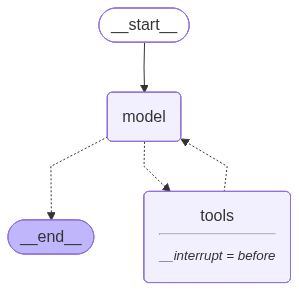

Version 3-HITL agent compiled successfully.


In [10]:
# TODO: Complete Version 3-HITL implementation

# 1) Create a MemorySaver checkpointer:
checkpointer_v3 = MemorySaver()

# 2) Create the agent using create_agent (NOT create_react_agent):
v3_hitl_agent = create_agent(
    model=llm,
    tools=[tavily_search],
    interrupt_before=["tools"],   # ← pause BEFORE the tools node runs
    checkpointer=checkpointer_v3,
)

# That's it — create_agent builds and compiles the full ReAct graph for you.

if v3_hitl_agent is not None:
    from IPython.display import Image, display
    display(Image(v3_hitl_agent.get_graph().draw_mermaid_png()))
    print("Version 3-HITL agent compiled successfully.")


In [11]:
# Version 3-HITL self-test

assert v3_hitl_agent is not None, "v3_hitl_agent is None — create it first."

config_v3 = {"configurable": {"thread_id": "hitl-3-test-1"}}

print("=" * 60)
print("Step 1: invoke → agent should pause before calling tools")
print("=" * 60)

result_v3_1 = v3_hitl_agent.invoke(
    {"messages": [HumanMessage(content="What is the current weather in New York City?")]},
    config=config_v3,
)

# With interrupt_before, the graph pauses and returns the current state.
# The last message will be an AIMessage with pending tool_calls.
last_paused_msg = result_v3_1["messages"][-1]
pending_tool_calls = getattr(last_paused_msg, "tool_calls", [])

print("Graph paused before tools. Pending tool calls:")
for tc in pending_tool_calls:
    print(f"  → {tc['name']}({tc['args']})")

assert pending_tool_calls, (
    "Expected pending tool_calls in the paused state — "
    "check that interrupt_before=[\"tools\"] is set and the checkpointer is provided."
)

print()
print("=" * 60)
print("Step 2: approve → resume with None (continues to tools node)")
print("=" * 60)

result_v3_2 = v3_hitl_agent.invoke(None, config=config_v3)

last_final = result_v3_2["messages"][-1]
text = getattr(last_final, "content", str(last_final))
assert len(str(text)) > 20, f"Answer too short: {text}"

print("Final answer:", str(text)[:400])
print()
print("Version 3-HITL test passed ✓")

Step 1: invoke → agent should pause before calling tools


INFO | HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.5-flash:generateContent "HTTP/1.1 200 OK"
INFO | tavily_search called | query=current weather in New York City


Graph paused before tools. Pending tool calls:
  → tavily_search({'query': 'current weather in New York City'})

Step 2: approve → resume with None (continues to tools node)


INFO | tavily_search done | 3 snippets returned
INFO | HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.5-flash:generateContent "HTTP/1.1 200 OK"


Final answer: [{'type': 'text', 'text': 'The current weather in New York City is 42.1°F and overcast, with a wind of 13.2 mph from the WNW. It feels like 35.0°F, and the humidity is 46%.', 'extras': {'signature': 'CoAFAb4+9vsDhV9yE+GRn1/6u2UJvecqrw+f0+NH5sl5BEu943yI9aswtbHFXqr+nqlxNUN9GEUn5YZjvr++BJah9ufXOqwpvWrxW42oLhmCHxPedznujumdVIEr5ihzWtJiNLD0b8/NYw6AAS8kjPueAozEl5wmo0H8C7ufKnHhXsN2zqg/O6nKx18oYk1EplATOCKL

Version 3-HITL test passed ✓


## Wrap-up

You have now built two Human-in-the-Loop patterns on top of a ReAct agent:

| Version | Pause mechanism | How to resume | Supports reject? |
|---------|----------------|---------------|------------------|
| 2.5-HITL | `interrupt()` inside a custom node | `Command(resume=True/False)` | ✓ Yes |
| 3-HITL | `interrupt_before=["tools"]` on `create_agent` | `None` (always continues) | ✗ No |

### Key takeaways
- **`interrupt()`** is the recommended pattern for HITL — it is dynamic, can carry a
  payload, and lets you branch based on the human's response.
- **`interrupt_before`** is a simple compile-time flag that requires no custom nodes —
  useful for debugging or simple approval flows where you always continue.
- Both require a **checkpointer** (e.g. `MemorySaver`) and a **thread ID** to persist
  state between invocations.
- Always use the **same `thread_id`** when resuming — this is how LangGraph knows which
  saved state to load.

### Optional extensions
- Add a validation loop: if the human provides invalid input, call `interrupt()` again
  inside a `while True` loop with a better prompt.
- Try streaming: `for chunk in v25_hitl_graph.stream(...): print(chunk)`
- Swap `MemorySaver` for `SqliteSaver` to persist state across kernel restarts.